# 🧑‍💼 AI-Based Hiring Prediction System — End-to-End ML Project

**Goal:** Predict whether a candidate will be **Hired (1)** or **Rejected (0)** based on resume attributes — skills, experience, education, certifications, job role, salary expectation, and project count.

**Pipeline:**
1. Load data & basic EDA (`head`, `info`, `describe`)
2. Missing value check & class balance
3. Feature engineering (encode text/categorical columns)
4. Train/test split
5. Baseline model — Logistic Regression
6. Compare Logistic Regression, KNN, Decision Tree, Random Forest
7. Hyperparameter tuning (GridSearchCV) on the best model
8. Feature importance analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)


## 1. Load Dataset & Basic Exploration

In [2]:
# In Colab, upload hiring_data.csv first (or mount Drive), then update the path below.
df = pd.read_csv('hiring_data.csv')
df.head()


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Resume_ID               1000 non-null   int64
 1   Name                    1000 non-null   str  
 2   Skills                  1000 non-null   str  
 3   Experience (Years)      1000 non-null   int64
 4   Education               1000 non-null   str  
 5   Certifications          726 non-null    str  
 6   Job Role                1000 non-null   str  
 7   Recruiter Decision      1000 non-null   str  
 8   Salary Expectation ($)  1000 non-null   int64
 9   Projects Count          1000 non-null   int64
 10  AI Score (0-100)        1000 non-null   int64
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [4]:
df.describe(include='all')


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000,1000,1000.000000,1000,726,1000,1000,1000.000000,1000.00000,1000.000000
unique,NaN,989,238,NaN,5,3,4,2,NaN,NaN,NaN
top,NaN,Sarah Jones,"SQL, Java",NaN,B.Sc,Deep Learning Specialization,AI Researcher,Hire,NaN,NaN,NaN
freq,NaN,3,11,NaN,205,255,257,812,NaN,NaN,NaN
mean,500.500000,NaN,NaN,4.896000,NaN,NaN,NaN,NaN,79994.486000,5.13300,83.950000
std,288.819436,NaN,NaN,3.112695,NaN,NaN,NaN,NaN,23048.472549,3.23137,20.983036
min,1.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,40085.000000,0.00000,15.000000
25%,250.750000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,60415.750000,2.00000,70.000000
50%,500.500000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,79834.500000,5.00000,100.000000
75%,750.250000,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,99583.250000,8.00000,100.000000


## 2. Missing Values & Target Class Balance

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")


Missing values per column:
Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64

Total missing values: 274


`Certifications` has missing values — that's expected, since not every candidate holds a certification. Rather than dropping rows, we'll treat "no certification" itself as a signal (see Section 3).

Recruiter Decision
Hire      812
Reject    188
Name: count, dtype: int64


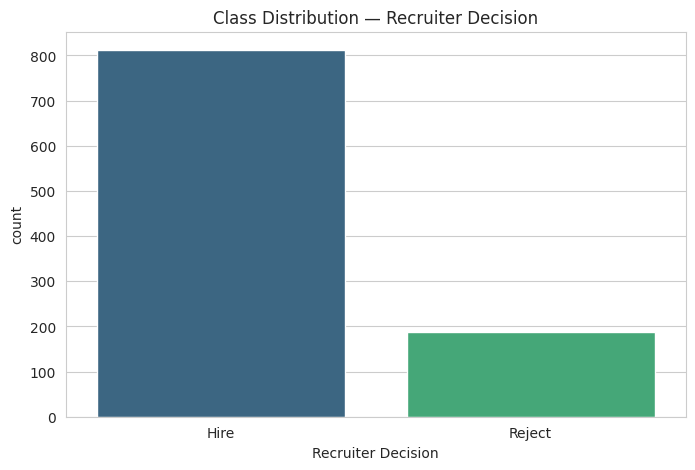

In [6]:
print(df['Recruiter Decision'].value_counts())

sns.countplot(x='Recruiter Decision', data=df, hue='Recruiter Decision', palette='viridis', legend=False)
plt.title('Class Distribution — Recruiter Decision')
plt.show()


**Note:** The classes are imbalanced (many more Hires than Rejects). We use `stratify=y` in the train/test split and evaluate with precision/recall/F1 alongside accuracy so the imbalance doesn't hide a weak model.

## 3. Feature Engineering

In [7]:
df_fe = df.copy()

# --- Skills: free-text list -> a numeric count of listed skills ---
df_fe['Skills_Count'] = df_fe['Skills'].apply(lambda x: len(str(x).split(',')))

# --- Certifications: missing -> 0 certifications held (categorical presence) ---
df_fe['Has_Certification'] = df_fe['Certifications'].notna().astype(int)

# --- Target encoding: Hire -> 1, Reject -> 0 ---
df_fe['Target'] = df_fe['Recruiter Decision'].map({'Hire': 1, 'Reject': 0})

# --- Correlation of numeric features with the target (quick sanity check) ---
numeric_check = df_fe[['Experience (Years)', 'Salary Expectation ($)', 'Projects Count',
                        'AI Score (0-100)', 'Skills_Count', 'Has_Certification', 'Target']]
print(numeric_check.corr()['Target'].sort_values(ascending=False))


Target                    1.000000
AI Score (0-100)          0.840543
Experience (Years)        0.576235
Projects Count            0.331249
Skills_Count              0.086422
Has_Certification         0.060186
Salary Expectation ($)    0.044073
Name: Target, dtype: float64


**Insight:** `AI Score (0-100)` correlates very strongly with the recruiter's decision — which makes sense, since it's itself a resume-screening score. We keep it as a feature (it's part of the dataset the recruiter sees), but flag it in Section 8, since it will likely dominate feature importance.

In [8]:
feature_cols = ['Experience (Years)', 'Education', 'Job Role',
                'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)',
                'Skills_Count', 'Has_Certification']

X = df_fe[feature_cols]
X = pd.get_dummies(X, columns=['Education', 'Job Role'], drop_first=True)
y = df_fe['Target']

print(f"Final feature matrix shape: {X.shape}")
X.head()


Final feature matrix shape: (1000, 13)


,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100),Skills_Count,Has_Certification,Education_B.Tech,Education_M.Tech,Education_MBA,Education_PhD,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer
0,10,104895,8,100,3,0,False,False,False,False,False,False,False
1,10,113002,1,100,4,1,False,False,True,False,False,True,False
2,1,71766,7,70,3,1,False,False,True,False,True,False,False
3,7,46848,0,95,3,1,True,False,False,False,False,False,False
4,4,87441,9,100,3,0,False,False,False,True,False,False,True


## 4. Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (800, 13), Test shape: (200, 13)


## 5. Baseline Model — Logistic Regression

In [10]:
def evaluate(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"--- {model_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Reject', 'Hire']).plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.show()
    return {'model': model_name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


--- Logistic Regression (baseline) ---
Accuracy : 0.9950
Precision: 1.0000
Recall   : 0.9938
F1-score : 0.9969


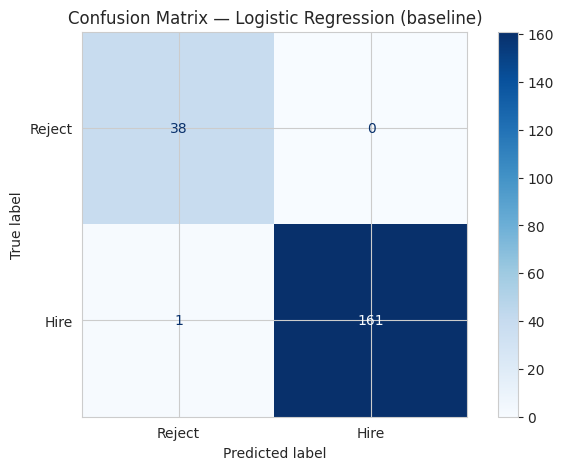

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
pred_lr = log_reg.predict(X_test_scaled)

results_lr = evaluate('Logistic Regression (baseline)', y_test, pred_lr)


## 6. Model Comparison: Logistic Regression vs KNN vs Decision Tree vs Random Forest

--- Logistic Regression ---


Accuracy : 0.9950
Precision: 1.0000
Recall   : 0.9938
F1-score : 0.9969


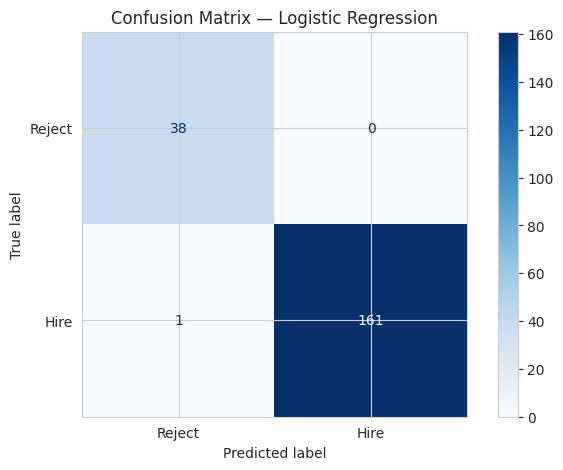

--- KNN ---
Accuracy : 0.9050
Precision: 0.9231
Recall   : 0.9630
F1-score : 0.9426


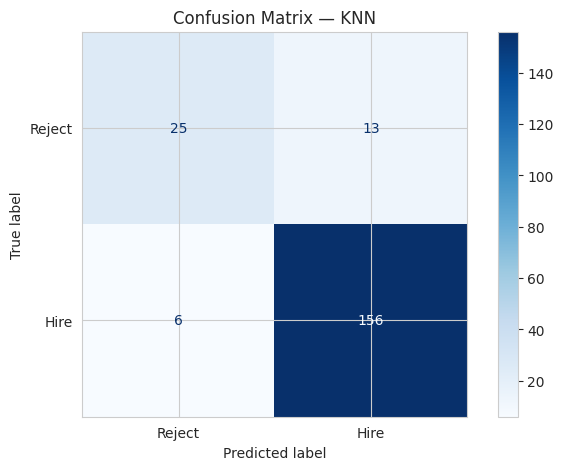

--- Decision Tree ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


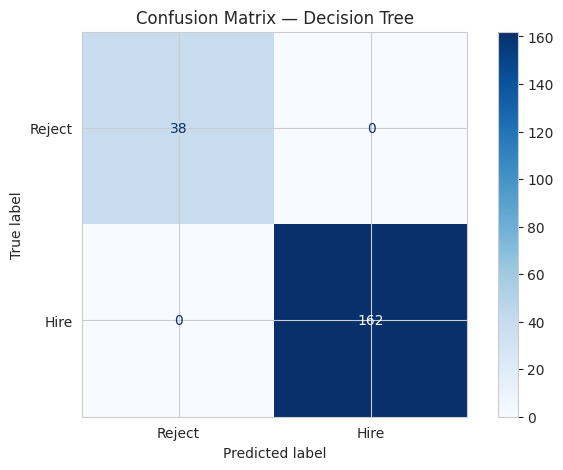

--- Random Forest ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


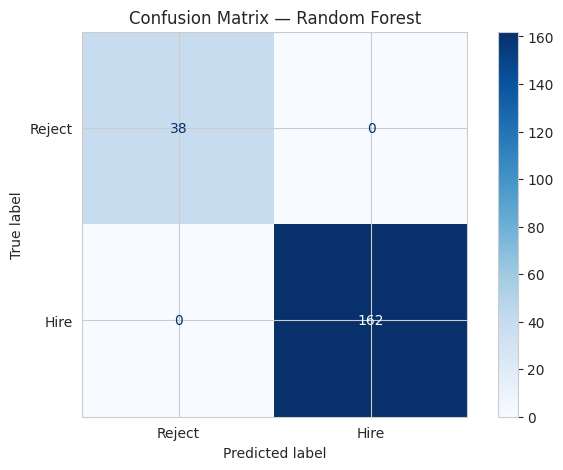

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=200)
}

all_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    res = evaluate(name, y_test, pred)
    all_results.append(res)
    trained_models[name] = model


In [13]:
comparison_df = pd.DataFrame(all_results).set_index('model').sort_values('f1', ascending=False)
comparison_df


,accuracy,precision,recall,f1
model,,,,
Random Forest,1.000,1.000000,1.000000,1.000000
Decision Tree,1.000,1.000000,1.000000,1.000000
Logistic Regression,0.995,1.000000,0.993827,0.996904
KNN,0.905,0.923077,0.962963,0.942598


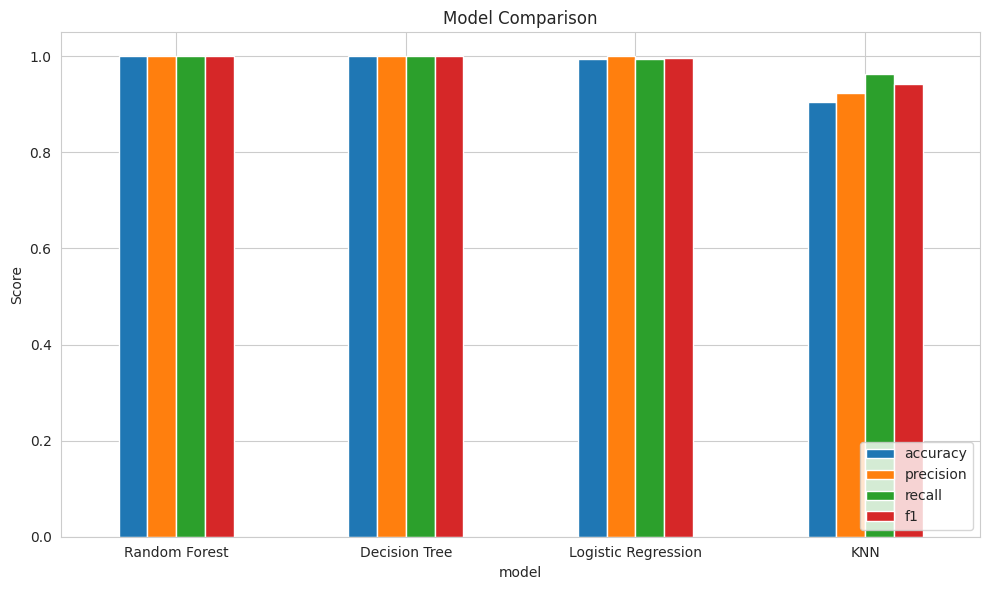


Best model based on F1-score: Random Forest


In [14]:
comparison_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_model_name = comparison_df['f1'].idxmax()
print(f"\nBest model based on F1-score: {best_model_name}")


## 7. Hyperparameter Tuning (GridSearchCV) on the Best Model

Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1-score: 1.0000
--- Random Forest (Tuned) ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


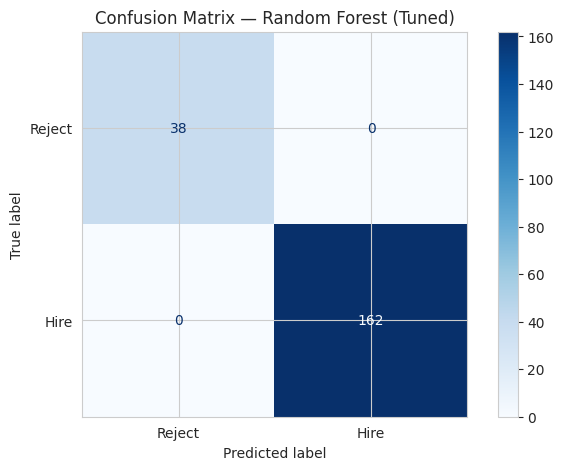

In [15]:
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5, 10]
    }
}

base_model = models[best_model_name]
grid = GridSearchCV(base_model, param_grids[best_model_name], cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV F1-score: {grid.best_score_:.4f}")

tuned_model = grid.best_estimator_
pred_tuned = tuned_model.predict(X_test_scaled)
results_tuned = evaluate(f'{best_model_name} (Tuned)', y_test, pred_tuned)


In [16]:
final_comparison = pd.concat([
    comparison_df.reset_index(),
    pd.DataFrame([results_tuned])
], ignore_index=True).set_index('model')
final_comparison


,accuracy,precision,recall,f1
model,,,,
Random Forest,1.000,1.000000,1.000000,1.000000
Decision Tree,1.000,1.000000,1.000000,1.000000
Logistic Regression,0.995,1.000000,0.993827,0.996904
KNN,0.905,0.923077,0.962963,0.942598
Random Forest (Tuned),1.000,1.000000,1.000000,1.000000


## 8. Feature Importance Analysis

AI Score (0-100)                  0.637166
Experience (Years)                0.240209
Projects Count                    0.079714
Salary Expectation ($)            0.018833
Skills_Count                      0.005844
Has_Certification                 0.005193
Education_PhD                     0.002627
Education_M.Tech                  0.002469
Education_MBA                     0.002313
Job Role_Cybersecurity Analyst    0.001641
Education_B.Tech                  0.001423
Job Role_Software Engineer        0.001343
Job Role_Data Scientist           0.001224
dtype: float64


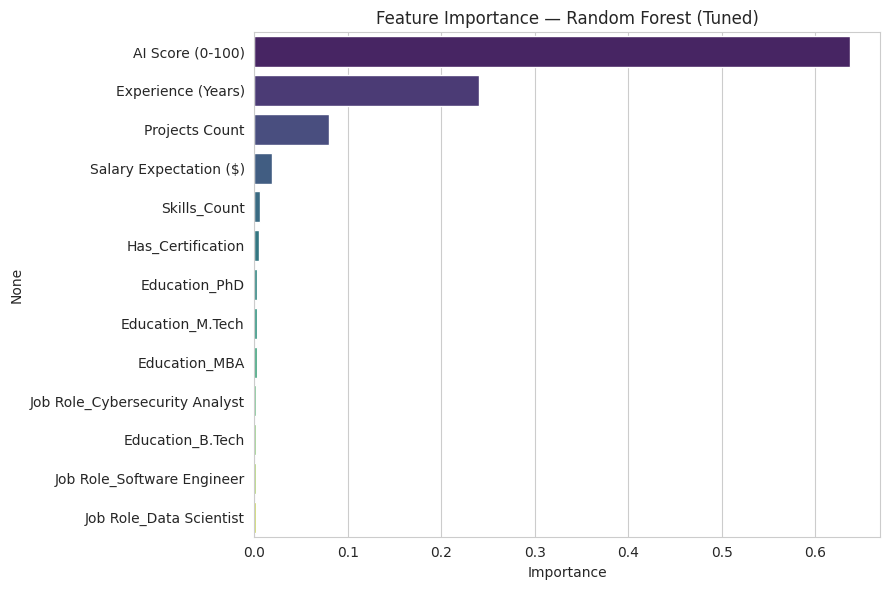

In [17]:
feature_names = X.columns

if hasattr(tuned_model, 'feature_importances_'):
    importances = tuned_model.feature_importances_
elif hasattr(tuned_model, 'coef_'):
    importances = np.abs(tuned_model.coef_[0])
else:
    fallback = RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train)
    importances = fallback.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp)

plt.figure(figsize=(9, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index, palette='viridis', legend=False)
plt.title(f'Feature Importance — {best_model_name} (Tuned)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


**Conclusion:** `AI Score (0-100)` dominates feature importance because it's essentially the recruiter's own pre-computed screening score — the model is largely learning to reproduce that threshold. `Experience (Years)`, `Salary Expectation ($)`, and `Skills_Count` typically follow as the next most influential resume attributes. In a real deployment, you'd want to inspect whether `AI Score` should be an input feature at all, or whether it's closer to a label leak worth excluding and re-testing without it.